In [1]:
import pandas as pd 
import numpy as np 
from pathlib import Path 

output_dir = Path(r"C:\f1 new\data") 
df = pd.read_parquet(output_dir / "f1_gold.parquet") 

reference = (
    df.groupby(['RoundNumber' , 'Compound'])
    .agg(
        AvgDegradationRate = ('DegradationRate', 'mean'),
        AvgDegradationSlope = ('DegradationSlope', 'mean') , 
        AvgTrackTemp = ('TrackTemp', 'mean') , 
        AvgAirTemp = ('AirTemp', 'mean') , 
        AvgHumidity = ('Humidity', 'mean') ,
        TotalLaps = ('LapNumber' , 'max') , 
        SCProbability = ('SCInNext3Laps' , 'mean') 
    )
    .reset_index()
) 

reference.to_parquet(output_dir / "reference.parquet", index=False , compression='snappy') 

print(f"Reference saved: {len(reference):,} rows") 
print(reference.head(10))

Reference saved: 87 rows
   RoundNumber      Compound  AvgDegradationRate  AvgDegradationSlope  \
0            1          HARD            0.788405             0.023170   
1            1  INTERMEDIATE            1.025510             0.004629   
2            1        MEDIUM            1.458687             0.069575   
3            1          SOFT            1.025661             0.030652   
4            2          HARD            0.475601             0.007468   
5            2        MEDIUM            0.393552             0.061418   
6            2          SOFT            0.572674             0.000000   
7            3          HARD            0.950426             0.064829   
8            3        MEDIUM            0.929596             0.097616   
9            3          SOFT            0.926438             0.144495   

   AvgTrackTemp  AvgAirTemp  AvgHumidity  TotalLaps  SCProbability  
0     25.584158   21.593003    38.440264       57.0       0.044224  
1     19.121891   15.835727    75

In [2]:
import joblib 

model = joblib.load(output_dir / "xgb_pit_model.pkl") 
reference = pd.read_parquet(output_dir / "reference.parquet") 

COMPOUND_MAX_LIFE = {
    'SOFT': 25, 'MEDIUM': 35, 'HARD': 45,
    'INTERMEDIATE': 30, 'WET': 40
}
COMPOUND_ENCODING = {
    'SOFT': 0, 'MEDIUM': 1, 'HARD': 2,
    'INTERMEDIATE': 3, 'WET': 4
}

def build_inference_laps(
    round_number: int,
    compound    : str,
    tyre_life   : int,
    position    : int,
    track_temp  : float = None,
) -> pd.DataFrame:

    ref = reference[
        (reference['RoundNumber'] == round_number) &
        (reference['Compound']    == compound)
    ]

    if ref.empty:
        print(f"⚠️ No reference for Round {round_number} + {compound}")
        return pd.DataFrame()

    ref          = ref.iloc[0]
    total_laps   = int(ref['TotalLaps'])
    avg_slope    = ref['AvgDegradationSlope']
    sc_prob      = ref['SCProbability']
    avg_track    = track_temp if track_temp else ref['AvgTrackTemp']
    avg_air      = ref['AvgAirTemp']
    avg_humid    = ref['AvgHumidity']
    compound_max = COMPOUND_MAX_LIFE.get(compound, 30)

    laps = []

    for lap_num in range(1, total_laps + 1):

        if lap_num < tyre_life:
            past_tyre_life = lap_num
            tyre_age_pct   = min(past_tyre_life / compound_max, 1.0)
            deg_rate       = avg_slope * past_tyre_life

        else:
            current_tyre_life = lap_num - tyre_life + tyre_life
            tyre_age_pct      = min(current_tyre_life / compound_max, 1.0)
            deg_rate          = avg_slope * current_tyre_life

        laps.append({
            'LapNumber'        : lap_num,
            'LapPct'           : round(lap_num / total_laps, 3),
            'CompoundEncoded'  : COMPOUND_ENCODING.get(compound, -1),
            'TyreLife'         : lap_num if lap_num < tyre_life else lap_num - tyre_life + tyre_life,
            'TyreAgePct'       : round(tyre_age_pct, 3),
            'DegradationRate'  : round(deg_rate, 3),
            'DegradationSlope' : round(avg_slope, 4),
            'Position'         : position,
            'SCInNext3Laps'    : sc_prob,
            'TrackTemp'        : avg_track,
            'AirTemp'          : avg_air,
            'Humidity'         : avg_humid,
            'WindSpeed'        : 2.0,
            'Rainfall'         : False,
        })

    return pd.DataFrame(laps)

In [3]:
inference_laps = build_inference_laps(
    round_number = 1,
    compound     = 'SOFT',
    tyre_life    = 10,
    position     = 1,
    track_temp   = 44.0
)

print(f"Laps built: {len(inference_laps)}")
print(inference_laps[['LapNumber', 'TyreLife', 
                    'TyreAgePct', 'DegradationRate']].head(15))

Laps built: 57
    LapNumber  TyreLife  TyreAgePct  DegradationRate
0           1         1        0.04            0.031
1           2         2        0.08            0.061
2           3         3        0.12            0.092
3           4         4        0.16            0.123
4           5         5        0.20            0.153
5           6         6        0.24            0.184
6           7         7        0.28            0.215
7           8         8        0.32            0.245
8           9         9        0.36            0.276
9          10        10        0.40            0.307
10         11        11        0.44            0.337
11         12        12        0.48            0.368
12         13        13        0.52            0.398
13         14        14        0.56            0.429
14         15        15        0.60            0.460


In [4]:
inference_laps['Phase'] = inference_laps['LapNumber'].apply(
    lambda x: 'Past' if x < 10 else ('Current' if x == 10 else 'Future')
)

print(inference_laps[['LapNumber', 'TyreLife', 
                    'DegradationRate', 'Phase']].iloc[7:14])

    LapNumber  TyreLife  DegradationRate    Phase
7           8         8            0.245     Past
8           9         9            0.276     Past
9          10        10            0.307  Current
10         11        11            0.337   Future
11         12        12            0.368   Future
12         13        13            0.398   Future
13         14        14            0.429   Future


In [5]:
def simulate_race(
    driver_laps  : pd.DataFrame,
    model,
    feature_cols : list,
    n_simulations: int = 10000
) -> dict:

    pit_votes = np.zeros(len(driver_laps))

    for _ in range(n_simulations):
        i = 0
        while i < len(driver_laps):
            lap       = driver_laps.iloc[i]
            features  = lap[feature_cols].values.reshape(1, -1)
            pit_proba = model.predict_proba(features)[0][1]

            sc_event = np.random.random() < lap['SCInNext3Laps'] * 0.3
            if sc_event:
                pit_proba = min(1.0, pit_proba * 1.5)

            if np.random.random() < pit_proba:
                pit_votes[i] += 1
                break
            else:
                i += 1

    pit_probability = pit_votes / n_simulations
    best_lap_index  = np.argmax(pit_probability)
    best_lap        = driver_laps.iloc[best_lap_index]['LapNumber']
    best_prob       = pit_probability[best_lap_index]

    return {
        'optimal_pit_lap' : int(best_lap),
        'probability'     : round(best_prob, 3),
        'pit_distribution': pit_probability,
        'lap_numbers'     : driver_laps['LapNumber'].values
    }

In [6]:
model = joblib.load(output_dir / "xgb_pit_model.pkl") 

feature_cols = [
    'LapNumber', 'LapPct',
    'CompoundEncoded', 'TyreLife', 'TyreAgePct',
    'DegradationRate', 'DegradationSlope',
    'Position', 'SCInNext3Laps',
    'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Rainfall'
]
result = simulate_race(inference_laps, model, feature_cols) 
print(f"Optimal Pit Lap: {result['optimal_pit_lap']}")
print(f"Probability of Pitting on that Lap: {result['probability']*100:.2f}%")


Optimal Pit Lap: 13
Probability of Pitting on that Lap: 16.80%


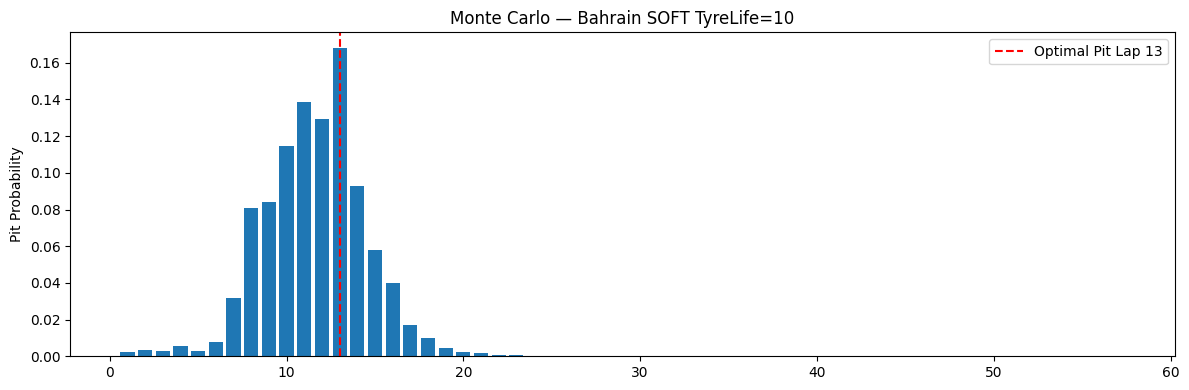

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.bar(result['lap_numbers'], result['pit_distribution'])
plt.axvline(x=result['optimal_pit_lap'], 
            color='red', linestyle='--', 
            label=f"Optimal Pit Lap {result['optimal_pit_lap']}")  
plt.ylabel('Pit Probability')
plt.title('Monte Carlo — Bahrain SOFT TyreLife=10')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
threshold = 0.10  

window = result['lap_numbers'][
    result['pit_distribution'] >= threshold
]

print(f"Optimal Pit Lap    : {result['optimal_pit_lap']}")
print(f"Recommended Window : Lap {window.min():.0f} → Lap {window.max():.0f}")
print(f"Peak Probability   : {result['probability']*100:.1f}%")

Optimal Pit Lap    : 13
Recommended Window : Lap 10 → Lap 13
Peak Probability   : 16.8%


In [ ]:
inference_laps = build_inference_laps(
    round_number = 1,
    compound     = 'HARD',
    tyre_life    = 1,
    position     = 1,
    track_temp   = 22.6
)

start  = time.time()
result = simulate_race(inference_laps, xgb, feature_cols)
elapsed = time.time() - start

print(f"Optimal Pit Lap : {result['optimal_pit_lap']}")
print(f"Probability     : {result['probability']*100:.1f}%")
print(f"Time            : {elapsed:.2f} sec")